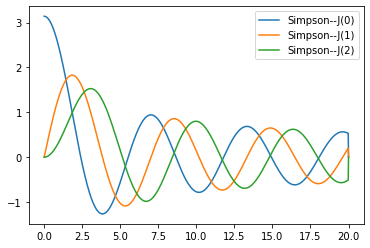

In [3]:
# Comp.Phys.HW3.Q1 : Exercise 5.4 Pt.1

import matplotlib.pyplot as plt
import numpy as np
from numpy import linspace

%matplotlib inline

a = 0
b = np.pi
N = 1000
h = (b - a) / N
# k = (2 * np.pi)/ wave_length
xpoints = np.linspace(0,20,N)
ypoints = np.zeros([1000])
m0 = 0
m1 = 1
m2 = 2


# Bessel-Func.
def J(m,x):
    
    # Integrand-Func.
    def f(theta):
        return np.cos(m * theta - x * np.sin(theta))
    
    s1 = 0.0
    for k in range(1, N, 2):
        s1 += f((a + k * h))
    s2 = 0.0
    for k in range(2, N, 2):
        s2 += f((a + k * h))
        
    s = f((a)) + f((b))
    
    s += 4 * s1
    s += 2 * s2
    
    return s * h / 3
    

# x-points loop -- m = 0 
for i in range(0,999):
    x = xpoints[i]
    ypoints[i] = J(m0,x)
    
plt.plot(xpoints, ypoints, label="Simpson--J(0)")
    
# x-points loop -- m = 1    
for i in range(0,999):
    x = xpoints[i]
    ypoints[i] = J(m1,x)

plt.plot(xpoints, ypoints, label="Simpson--J(1)")


for i in range(0,999):
    x = xpoints[i]
    ypoints[i] = J(m2,x)
    
plt.plot(xpoints, ypoints, label="Simpson--J(2)")
    
    
plt.legend()

# Looks good -- doesn't mean it's correct...

In [ ]:
# Comp.Phys.HW3.Q1 : Exercise 5.4 Pt.2

import pylab as plt
import numpy as np

# parameters

a = 0
b = np.pi
N = 1000
h = ((b - a) / N)
wave_length = .5 # 500nm
k = (2 * np.pi)/ wave_length
points = 500

# initial condition
I0 = 1

# seperation between rings
seperation = 0.003


# same J() func. code from Pt.1 
def J(m,x):
    
    # Integrand-Func.
    def f(theta):
        return (1/np.pi) * np.cos(m * theta - x * np.sin(theta))
    
    s1 = 0.0
    for k in range(1, N, 2):
        s1 += f((a + k * h))

    s2 = 0.0
    for k in range(2, N, 2):
        s2 += f((a + k * h))

    s = f((a)) + f((b))

    s += 4 * s1
    s += 2 * s2

    return s * h / 3


# intensity func -- considers wavelength and distance
def I(wavelength,r):
    return ((J(1, k * r)) / (k * r))**2


# empty list to store x-vals and y-vals
intensity = np.empty([points, points],float)

# for-loop  --> y-vals, x-vals, magnitude
for i in range(points):
    y = seperation * (i - points / 2)
    for j in range(points):
        x = seperation * (j - points / 2)
        magnitude = np.sqrt((x)**2 + (y)**2)
        r = magnitude
        
        # setting up the limit
        if r < 0.0000001: # less than 1 micrometer
            intensity[i,j] = wave_length
        else:
            intensity[i,j] = I0 * I(wave_length, r)

# plotting       
plt.imshow(intensity,vmax=0.005,cmap='hot')
plt.show()

/var/folders/nq/gzwf125s36x6jsc6_zqj0gdc0000gn/T/ipykernel_93007/442285784.py:50: RuntimeWarning: invalid value encountered in double_scalars
  return (4*x**3)/np.sqrt(E - V(x))


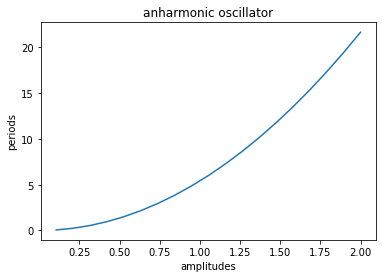

In [4]:
# Comp.Phys.HW3.Q2 : Exercise 5.10

import matplotlib.pyplot as plt
import numpy as np
from numpy import linspace, pi, cos, tan, ones, copy

m = 1
N = 20

def gaussxw(N):
    a = linspace(3, 4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))
    
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N, float)
        p1 = copy(x)
        for k in range(1,N):
            p0, p1 = p1, ((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1) * (p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))
    
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)
    return x,w


def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a), 0.5*(b-a)*w


def integrateGauss(N,a,b,f):
    integral = 0.0
    x,w = gaussxwab(N,a,b)
    
    for k in range(N):
        integral = integral+w[k]*f(x[k])
    return integral

def T(amp):
    
    def V(x):
        return x**4
    
    E = V(amp)
    
    def f(x):
        return (4*x**3)/np.sqrt(E - V(x))
    
    integral = integrateGauss(N,0,amp,f)
    period = np.sqrt(8 * m) * integral
    return period

#setting up the plot
amp_vals = np.linspace(0, 2, 20)
periods = [T(amp) for amp in amp_vals]
plt.plot(amp_vals, periods)
plt.xlabel('amplitudes')
plt.ylabel('periods')
plt.title('anharmonic oscillator')
plt.show()

# as amplitude increases, period increases -- V(a) gains more potential energy
# as period diverges, amplitude decreases

Text(0.5, 1.0, 'Intensity of Diffracted Sound Wave')

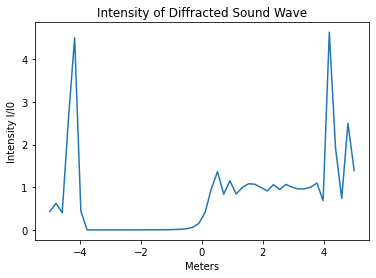

In [6]:
# Comp.Phys.HW3.Q3 : Exercise 5.11

import matplotlib.pyplot as plt
import numpy as np
from numpy import linspace, pi, cos, tan, ones, copy


# parameters
N = 50
wave_length = 1 # meter
z = 3 # meter

# gaussian code
def gaussxw(N):
    a = linspace(3, 4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))
    
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N, float)
        p1 = copy(x)
        for k in range(1,N):
            p0, p1 = p1, ((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1) * (p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))
    
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)
    return x,w


def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a), 0.5*(b-a)*w

# integration
def integrateGauss(N,a,b,f):
    integral = 0.0
    x,w = gaussxwab(N,a,b)
    
    for k in range(N):
        integral = integral+w[k]*f(x[k])
    return integral


# funcs from textbook
def C(x):
    u = x * np.sqrt(2/wave_length * z)
    def f(t):
        return np.cos(.5 * np.pi * t**2)
    integral = integrateGauss(N,0,u,f)
    return integral

def S(x):
    u = x * np.sqrt(2/wave_length * z)
    def f(t):
        return np.sin(.5 * np.pi * t**2)
    integral = integrateGauss(N,0,u,f)
    return integral

# Resulting Intensity / Initial Intensity before Diffrac.
def I_I0(x):
    u = x * np.sqrt(2/wave_length * z)
    return (1/8) * ((2 * C(x) + 1)**2 + (2 * S(x) + 1)**2)


# plotting I_I0 from x = -5 to x = 5
xvals = np.linspace(-5,5,N)
yvals = [I_I0(x) for x in xvals]
plt.plot(xvals, yvals)
plt.xlabel('Meters')
plt.ylabel('Intensity I/I0')
plt.title('Intensity of Diffracted Sound Wave')
